In [3]:
# Install the libraries we need
!pip install transformers datasets torch scikit-learn pandas matplotlib seaborn accelerate


In [4]:
import torch
print("GPU available:", torch.cuda.is_available())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

GPU available: True
Device name: Tesla T4


In [5]:
from datasets import load_dataset

# Load IMDB (movie reviews) - binary labeled: 0 = negative, 1 = positive
imdb = load_dataset("stanfordnlp/imdb")

# Load Amazon Polarity (product reviews) - binary labeled: 0 = negative, 1 = positive
amazon = load_dataset("fancyzhx/amazon_polarity")

# Load TweetEval sentiment (tweets) - 3-class: 0 = negative, 1 = neutral, 2 = positive
tweets = load_dataset("cardiffnlp/tweet_eval", "sentiment")

print("IMDB:", imdb)
print("Amazon:", amazon)
print("Tweets:", tweets)

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

sentiment/validation-00000-of-00001.parq(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

IMDB: DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})
Amazon: DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 3600000
    })
    test: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 400000
    })
})
Tweets: DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [6]:
import pandas as pd

# Convert each dataset's train split into a pandas DataFrame for easy inspection
imdb_df = imdb["train"].to_pandas()
amazon_df = amazon["train"].to_pandas()
tweets_df = tweets["train"].to_pandas()

# Standardize: rename Amazon's "content" column to "text" so all three match
amazon_df = amazon_df.rename(columns={"content": "text"})

# Quick look at each
print("IMDB sample:")
print(imdb_df[["text", "label"]].head(2))
print("\nAmazon sample:")
print(amazon_df[["text", "label"]].head(2))
print("\nTweets sample:")
print(tweets_df[["text", "label"]].head(2))

IMDB sample:
                                                text  label
0  I rented I AM CURIOUS-YELLOW from my video sto...      0
1  "I Am Curious: Yellow" is a risible and preten...      0

Amazon sample:
                                                text  label
0  This sound track was beautiful! It paints the ...      1
1  I'm reading a lot of reviews saying that this ...      1

Tweets sample:
                                                text  label
0  "QT @user In the original draft of the 7th boo...      2
1  "Ben Smith / Smith (concussion) remains out of...      1


IMDB label counts:
 label
0    12500
1    12500
Name: count, dtype: int64

Amazon label counts:
 label
1    1800000
0    1800000
Name: count, dtype: int64

Tweets label counts:
 label
1    20673
2    17849
0     7093
Name: count, dtype: int64

IMDB word count stats:
 count    25000.000000
mean       233.787200
std        173.733032
min         10.000000
25%        127.000000
50%        174.000000
75%        284.000000
max       2470.000000
Name: word_count, dtype: float64

Amazon word count stats:
 count    3.600000e+06
mean     7.416885e+01
std      4.229870e+01
min      1.000000e+00
25%      3.900000e+01
50%      6.600000e+01
75%      1.030000e+02
max      2.540000e+02
Name: word_count, dtype: float64

Tweets word count stats:
 count    45615.000000
mean        19.237444
std          4.935990
min          1.000000
25%         16.000000
50%         20.000000
75%         23.000000
max         35.000000
Name: word_count, dtype: float64


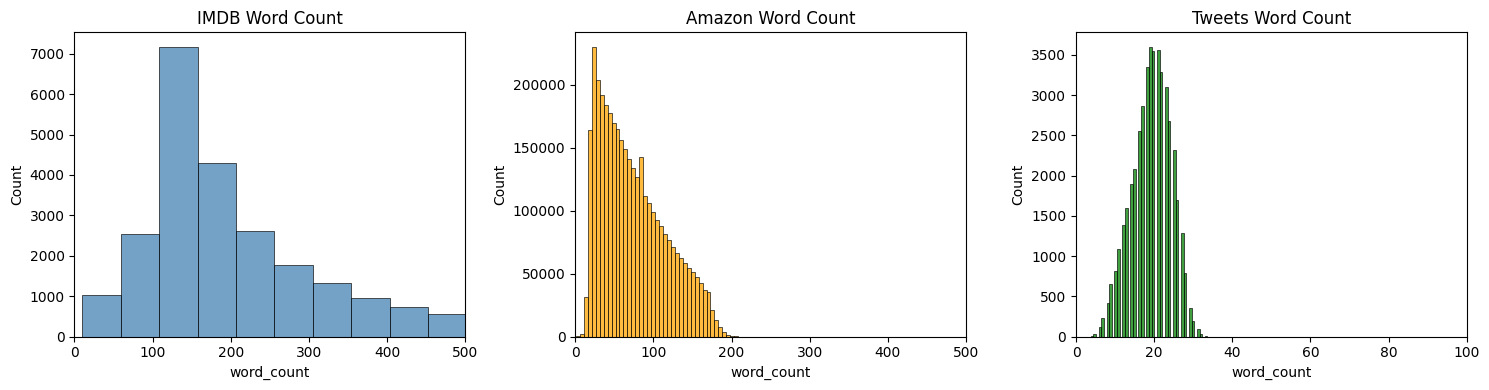

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Label balance ---
print("IMDB label counts:\n", imdb_df["label"].value_counts())
print("\nAmazon label counts:\n", amazon_df["label"].value_counts())
print("\nTweets label counts:\n", tweets_df["label"].value_counts())

# --- 2. Text length (in words) ---
imdb_df["word_count"] = imdb_df["text"].apply(lambda x: len(x.split()))
amazon_df["word_count"] = amazon_df["text"].apply(lambda x: len(x.split()))
tweets_df["word_count"] = tweets_df["text"].apply(lambda x: len(x.split()))

print("\nIMDB word count stats:\n", imdb_df["word_count"].describe())
print("\nAmazon word count stats:\n", amazon_df["word_count"].describe())
print("\nTweets word count stats:\n", tweets_df["word_count"].describe())

# --- 3. Visualize ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(imdb_df["word_count"], bins=50, ax=axes[0], color="steelblue")
axes[0].set_title("IMDB Word Count")
axes[0].set_xlim(0, 500)

sns.histplot(amazon_df["word_count"], bins=50, ax=axes[1], color="orange")
axes[1].set_title("Amazon Word Count")
axes[1].set_xlim(0, 500)

sns.histplot(tweets_df["word_count"], bins=50, ax=axes[2], color="green")
axes[2].set_title("Tweets Word Count")
axes[2].set_xlim(0, 100)

plt.tight_layout()
plt.show()

In [8]:
import re
import pandas as pd

def clean_text(text):
    text = re.sub(r"http\S+|www\S+", "", text)      # remove URLs
    text = re.sub(r"<.*?>", "", text)                 # remove HTML tags (IMDB has some)
    text = re.sub(r"@\w+", "@user", text)              # normalize tweet mentions
    text = re.sub(r"\s+", " ", text).strip()           # collapse extra whitespace
    return text

# Apply light cleaning
imdb_df["text"] = imdb_df["text"].apply(clean_text)
amazon_df["text"] = amazon_df["text"].apply(clean_text)
tweets_df["text"] = tweets_df["text"].apply(clean_text)

# --- Balanced sampling: 15,000 rows per domain ---
SAMPLE_SIZE = 15000

imdb_sampled = imdb_df.groupby("label", group_keys=False).apply(
    lambda x: x.sample(min(len(x), SAMPLE_SIZE // 2), random_state=42)
).reset_index(drop=True)

amazon_sampled = amazon_df.groupby("label", group_keys=False).apply(
    lambda x: x.sample(min(len(x), SAMPLE_SIZE // 2), random_state=42)
).reset_index(drop=True)

# Tweets: stratified sample proportional to original class distribution
tweets_sampled = tweets_df.groupby("label", group_keys=False).apply(
    lambda x: x.sample(min(len(x), int(SAMPLE_SIZE * (len(x)/len(tweets_df)))), random_state=42)
).reset_index(drop=True)

print("IMDB sampled:", imdb_sampled["label"].value_counts().to_dict(), "| total:", len(imdb_sampled))
print("Amazon sampled:", amazon_sampled["label"].value_counts().to_dict(), "| total:", len(amazon_sampled))
print("Tweets sampled:", tweets_sampled["label"].value_counts().to_dict(), "| total:", len(tweets_sampled))

/tmp/ipykernel_2773/4076452944.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  imdb_sampled = imdb_df.groupby("label", group_keys=False).apply(


IMDB sampled: {0: 7500, 1: 7500} | total: 15000
Amazon sampled: {0: 7500, 1: 7500} | total: 15000
Tweets sampled: {1: 6798, 2: 5869, 0: 2332} | total: 14999


/tmp/ipykernel_2773/4076452944.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  amazon_sampled = amazon_df.groupby("label", group_keys=False).apply(
/tmp/ipykernel_2773/4076452944.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tweets_sampled = tweets_df.groupby("label", group_keys=False).apply(


In [9]:
imdb_sampled = imdb_df.groupby("label", group_keys=False)[imdb_df.columns.tolist()].apply(
    lambda x: x.sample(min(len(x), SAMPLE_SIZE // 2), random_state=42)
).reset_index(drop=True)

amazon_sampled = amazon_df.groupby("label", group_keys=False)[amazon_df.columns.tolist()].apply(
    lambda x: x.sample(min(len(x), SAMPLE_SIZE // 2), random_state=42)
).reset_index(drop=True)

tweets_sampled = tweets_df.groupby("label", group_keys=False)[tweets_df.columns.tolist()].apply(
    lambda x: x.sample(min(len(x), int(SAMPLE_SIZE * (len(x)/len(tweets_df)))), random_state=42)
).reset_index(drop=True)

print("IMDB sampled:", imdb_sampled["label"].value_counts().to_dict(), "| total:", len(imdb_sampled))
print("Amazon sampled:", amazon_sampled["label"].value_counts().to_dict(), "| total:", len(amazon_sampled))
print("Tweets sampled:", tweets_sampled["label"].value_counts().to_dict(), "| total:", len(tweets_sampled))

IMDB sampled: {0: 7500, 1: 7500} | total: 15000
Amazon sampled: {0: 7500, 1: 7500} | total: 15000
Tweets sampled: {1: 6798, 2: 5869, 0: 2332} | total: 14999


In [10]:
from transformers import AutoTokenizer

# Load BERT's tokenizer (matches the pretrained model we'll use in Step 6)
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Try it on one example sentence to see what it actually does
sample_text = imdb_sampled["text"].iloc[0]
print("Original text:\n", sample_text[:200], "...\n")

tokens = tokenizer.tokenize(sample_text)
print("Tokenized (first 20 tokens):\n", tokens[:20])

encoded = tokenizer(sample_text, truncation=True, padding="max_length", max_length=256)
print("\nEncoded input_ids (first 20):\n", encoded["input_ids"][:20])
print("\nAttention mask (first 20):\n", encoded["attention_mask"][:20])

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Original text:
 Wow, what a total let down! The fact people think this film is scary is ridiculous. The special effects were a direct rip-off of "The ring." The story? Was there one? Not in my opinion..Just a bunch o ...

Tokenized (first 20 tokens):
 ['wow', ',', 'what', 'a', 'total', 'let', 'down', '!', 'the', 'fact', 'people', 'think', 'this', 'film', 'is', 'scary', 'is', 'ridiculous', '.', 'the']

Encoded input_ids (first 20):
 [101, 10166, 1010, 2054, 1037, 2561, 2292, 2091, 999, 1996, 2755, 2111, 2228, 2023, 2143, 2003, 12459, 2003, 9951, 1012]

Attention mask (first 20):
 [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [11]:
import torch
from torch.utils.data import Dataset, DataLoader

# Remap IMDB and Amazon labels to 3-class scheme: 0=negative, 1=neutral, 2=positive
imdb_sampled["label"] = imdb_sampled["label"].map({0: 0, 1: 2})
amazon_sampled["label"] = amazon_sampled["label"].map({0: 0, 1: 2})
# Tweets already uses 0=negative, 1=neutral, 2=positive - no change needed

MAX_LEN = 256

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(label, dtype=torch.long)
        }

# Create Dataset objects for each domain
imdb_dataset = SentimentDataset(imdb_sampled["text"], imdb_sampled["label"], tokenizer, MAX_LEN)
amazon_dataset = SentimentDataset(amazon_sampled["text"], amazon_sampled["label"], tokenizer, MAX_LEN)
tweets_dataset = SentimentDataset(tweets_sampled["text"], tweets_sampled["label"], tokenizer, MAX_LEN)

print("IMDB dataset size:", len(imdb_dataset))
print("Amazon dataset size:", len(amazon_dataset))
print("Tweets dataset size:", len(tweets_dataset))

# Quick sanity check on one item
sample_item = imdb_dataset[0]
print("\nSample item shapes:")
print("input_ids:", sample_item["input_ids"].shape)
print("attention_mask:", sample_item["attention_mask"].shape)
print("label:", sample_item["label"])

IMDB dataset size: 15000
Amazon dataset size: 15000
Tweets dataset size: 14999

Sample item shapes:
input_ids: torch.Size([256])
attention_mask: torch.Size([256])
label: tensor(0)


In [12]:
from transformers import BertForSequenceClassification
import torch

# Check device (should say cuda since we confirmed GPU earlier)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load pre-trained BERT with a classification head for 3 classes
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3  # negative, neutral, positive
)

model = model.to(device)

print("\nModel loaded successfully.")
print("Number of parameters:", sum(p.numel() for p in model.parameters()))

Using device: cuda


model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Model loaded successfully.
Number of parameters: 109484547


In [13]:
from sklearn.model_selection import train_test_split

def split_domain(df, test_size=0.2):
    train_df, test_df = train_test_split(
        df, test_size=test_size, stratify=df["label"], random_state=42
    )
    return train_df.reset_index(drop=True), test_df.reset_index(drop=True)

imdb_train, imdb_test = split_domain(imdb_sampled)
amazon_train, amazon_test = split_domain(amazon_sampled)
tweets_train, tweets_test = split_domain(tweets_sampled)

print("IMDB:", len(imdb_train), "train /", len(imdb_test), "test")
print("Amazon:", len(amazon_train), "train /", len(amazon_test), "test")
print("Tweets:", len(tweets_train), "train /", len(tweets_test), "test")

# Combine all training data into one multi-domain training set
import pandas as pd
combined_train = pd.concat([imdb_train, amazon_train, tweets_train], ignore_index=True)
combined_train = combined_train.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

print("\nCombined multi-domain training set size:", len(combined_train))
print("Combined label distribution:", combined_train["label"].value_counts().to_dict())

IMDB: 12000 train / 3000 test
Amazon: 12000 train / 3000 test
Tweets: 11999 train / 3000 test

Combined multi-domain training set size: 35999
Combined label distribution: {2: 16695, 0: 13866, 1: 5438}


In [14]:
from transformers import TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

# Build the combined training dataset object (reusing our SentimentDataset class)
combined_train_dataset = SentimentDataset(
    combined_train["text"], combined_train["label"], tokenizer, MAX_LEN
)

# A small validation set carved out of the combined training data, to monitor training
from sklearn.model_selection import train_test_split as tts
train_texts, val_texts, train_labels, val_labels = tts(
    combined_train["text"], combined_train["label"],
    test_size=0.1, stratify=combined_train["label"], random_state=42
)

train_dataset = SentimentDataset(train_texts, train_labels, tokenizer, MAX_LEN)
val_dataset = SentimentDataset(val_texts, val_labels, tokenizer, MAX_LEN)

print("Final training set:", len(train_dataset))
print("Validation set:", len(val_dataset))

# Function Trainer will call after each evaluation step
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="weighted")
    return {"accuracy": acc, "f1": f1}

training_args = TrainingArguments(
    output_dir="./bert_sentiment_results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("\nTrainer is ready. Starting training now — this will take a while, watch the progress bar.")
trainer.train()

Final training set: 32399
Validation set: 3600

Trainer is ready. Starting training now — this will take a while, watch the progress bar.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.389610,0.388958,0.834167,0.832815


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.389610,0.388958,0.834167,0.832815
2,0.249400,0.367307,0.864444,0.865250
3,0.126162,0.516450,0.862222,0.862599


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=6075, training_loss=0.2786447430049441, metrics={'train_runtime': 4340.935, 'train_samples_per_second': 22.391, 'train_steps_per_second': 1.399, 'total_flos': 1.2786917431454208e+16, 'train_loss': 0.2786447430049441, 'epoch': 3.0})

In [15]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = "/content/drive/MyDrive/fincard_bert_project"
os.makedirs(SAVE_DIR, exist_ok=True)

model.save_pretrained(f"{SAVE_DIR}/bert_sentiment_model")
tokenizer.save_pretrained(f"{SAVE_DIR}/bert_sentiment_model")

print("Model and tokenizer saved to Google Drive successfully.")

ValueError: mount failed

In [16]:
try:
    print(model)
except NameError:
    print("CONFIRMED: model is gone. Training will need to be redone.")

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [17]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [18]:
import os
SAVE_DIR = "/content/drive/MyDrive/fincard_bert_project"
os.makedirs(SAVE_DIR, exist_ok=True)

model.save_pretrained(f"{SAVE_DIR}/bert_sentiment_model")
tokenizer.save_pretrained(f"{SAVE_DIR}/bert_sentiment_model")

print("✅ Model and tokenizer saved to Google Drive successfully.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model and tokenizer saved to Google Drive successfully.


In [19]:
import os
LOCAL_SAVE_DIR = "/content/bert_sentiment_model_backup"
os.makedirs(LOCAL_SAVE_DIR, exist_ok=True)

model.save_pretrained(LOCAL_SAVE_DIR)
tokenizer.save_pretrained(LOCAL_SAVE_DIR)

print("✅ Backed up locally (temporary). Still need Drive for permanent safety.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Backed up locally (temporary). Still need Drive for permanent safety.


In [20]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [21]:
import shutil, os

SAVE_DIR = "/content/drive/MyDrive/fincard_bert_project"
os.makedirs(SAVE_DIR, exist_ok=True)

# Copy the local backup into Drive (permanent storage)
shutil.copytree(
    "/content/bert_sentiment_model_backup",
    f"{SAVE_DIR}/bert_sentiment_model",
    dirs_exist_ok=True
)

print("✅ Model copied to Google Drive permanently.")
print("Files now in Drive:", os.listdir(f"{SAVE_DIR}/bert_sentiment_model"))

✅ Model copied to Google Drive permanently.
Files now in Drive: ['config.json', 'model.safetensors', 'tokenizer_config.json', 'tokenizer.json']


In [22]:
imdb_sampled.to_pickle(f"{SAVE_DIR}/imdb_sampled.pkl")
amazon_sampled.to_pickle(f"{SAVE_DIR}/amazon_sampled.pkl")
tweets_sampled.to_pickle(f"{SAVE_DIR}/tweets_sampled.pkl")

# Also save the test sets we'll need for Step 9 evaluation
imdb_test.to_pickle(f"{SAVE_DIR}/imdb_test.pkl")
amazon_test.to_pickle(f"{SAVE_DIR}/amazon_test.pkl")
tweets_test.to_pickle(f"{SAVE_DIR}/tweets_test.pkl")

print("✅ All datasets (including test sets) saved to Drive.")

✅ All datasets (including test sets) saved to Drive.


In [24]:
def evaluate_domain(test_df, domain_name):
    dataset = SentimentDataset(test_df["text"], test_df["label"], tokenizer, MAX_LEN)
    loader = DataLoader(dataset, batch_size=32, shuffle=False)

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="weighted")

    print(f"\n{'='*50}")
    print(f"DOMAIN: {domain_name}")
    print(f"{'='*50}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Weighted F1: {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(
        all_labels, all_preds,
        labels=[0, 1, 2],
        target_names=["Negative", "Neutral", "Positive"],
        zero_division=0
    ))

    cm = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2])
    print("Confusion Matrix (rows=actual, cols=predicted; order: Negative, Neutral, Positive):")
    print(cm)

    return {"domain": domain_name, "accuracy": acc, "f1": f1, "preds": all_preds, "labels": all_labels, "confusion_matrix": cm}

# Re-run all three (fast - just re-evaluating, not retraining)
imdb_results = evaluate_domain(imdb_test, "IMDB (Movie Reviews)")
amazon_results = evaluate_domain(amazon_test, "Amazon (Product Reviews)")
tweets_results = evaluate_domain(tweets_test, "Tweets (TweetEval)")


DOMAIN: IMDB (Movie Reviews)
Accuracy: 0.9273
Weighted F1: 0.9273

Classification Report:
              precision    recall  f1-score   support

    Negative       0.93      0.92      0.93      1500
     Neutral       0.00      0.00      0.00         0
    Positive       0.92      0.93      0.93      1500

    accuracy                           0.93      3000
   macro avg       0.62      0.62      0.62      3000
weighted avg       0.93      0.93      0.93      3000

Confusion Matrix (rows=actual, cols=predicted; order: Negative, Neutral, Positive):
[[1381    0  119]
 [   0    0    0]
 [  99    0 1401]]

DOMAIN: Amazon (Product Reviews)
Accuracy: 0.9310
Weighted F1: 0.9319

Classification Report:
              precision    recall  f1-score   support

    Negative       0.94      0.92      0.93      1500
     Neutral       0.00      0.00      0.00         0
    Positive       0.92      0.95      0.93      1500

    accuracy                           0.93      3000
   macro avg       0.6

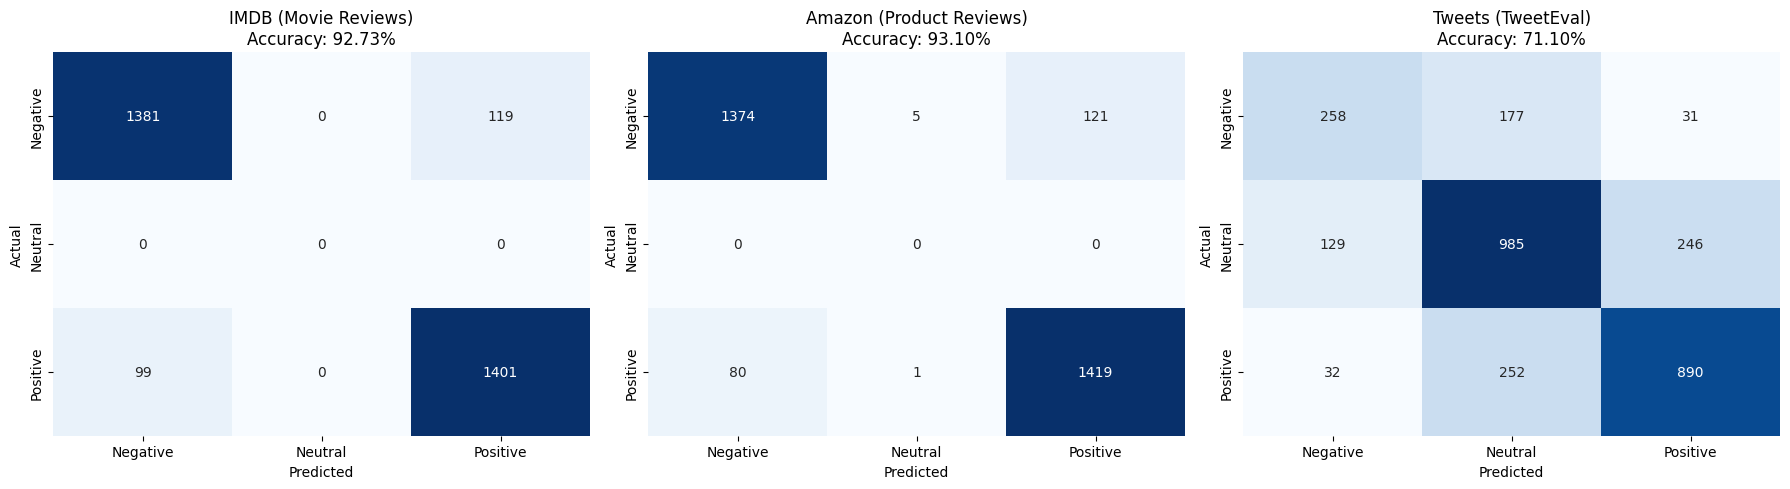

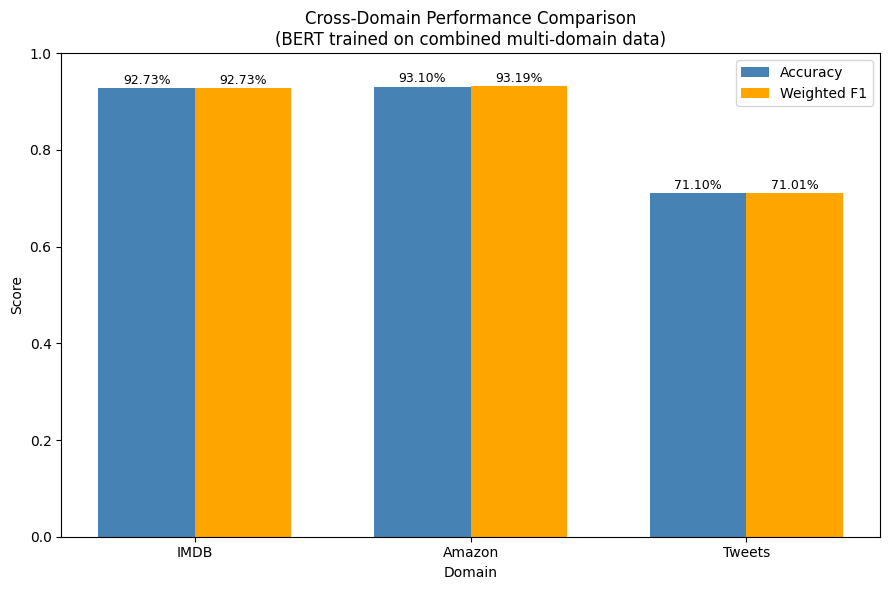

✅ Both charts saved to Drive as PNG files, ready to insert into your report.


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

labels_names = ["Negative", "Neutral", "Positive"]

# --- 1. Confusion matrix heatmaps, side by side ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

results_list = [imdb_results, amazon_results, tweets_results]

for ax, result in zip(axes, results_list):
    sns.heatmap(
        result["confusion_matrix"],
        annot=True, fmt="d", cmap="Blues",
        xticklabels=labels_names, yticklabels=labels_names,
        ax=ax, cbar=False
    )
    ax.set_title(f"{result['domain']}\nAccuracy: {result['accuracy']:.2%}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/fincard_bert_project/confusion_matrices.png", dpi=150)
plt.show()

# --- 2. Cross-domain comparison bar chart ---
domains = [r["domain"].split(" (")[0] for r in results_list]  # shorten names
accuracies = [r["accuracy"] for r in results_list]
f1_scores = [r["f1"] for r in results_list]

x = np.arange(len(domains))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
bars1 = ax.bar(x - width/2, accuracies, width, label="Accuracy", color="steelblue")
bars2 = ax.bar(x + width/2, f1_scores, width, label="Weighted F1", color="orange")

ax.set_xlabel("Domain")
ax.set_ylabel("Score")
ax.set_title("Cross-Domain Performance Comparison\n(BERT trained on combined multi-domain data)")
ax.set_xticks(x)
ax.set_xticklabels(domains)
ax.set_ylim(0, 1.0)
ax.legend()

# Add value labels on top of bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2%}', xy=(bar.get_x() + bar.get_width()/2, height),
                     xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/fincard_bert_project/cross_domain_comparison.png", dpi=150)
plt.show()

print("✅ Both charts saved to Drive as PNG files, ready to insert into your report.")

In [ ]:
import gradio as gr
import torch

def predict_sentiment(text):
    if not text.strip():
        return "Please enter some text."

    model.eval()
    encoding = tokenizer(
        text, truncation=True, padding="max_length",
        max_length=MAX_LEN, return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(**encoding)
        probs = torch.softmax(outputs.logits, dim=1)[0]
        pred_class = torch.argmax(probs).item()

    labels_map = {0: "Negative 😞", 1: "Neutral 😐", 2: "Positive 😊"}
    confidence = probs[pred_class].item()

    result = f"**Prediction: {labels_map[pred_class]}**\n\nConfidence: {confidence:.2%}\n\n"
    result += f"(Negative: {probs[0]:.2%} | Neutral: {probs[1]:.2%} | Positive: {probs[2]:.2%})"
    return result

demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=3, placeholder="Type a movie review, product review, or tweet here...", label="Enter Text"),
    outputs=gr.Markdown(label="Sentiment Prediction"),
    title="FinCard AI Sentiment Engine — Multi-Domain Sentiment Analysis (BERT)",
    description="A BERT-based sentiment classifier trained across movie reviews, product reviews, and tweets. Try text from any domain!",
    examples=[
        ["This movie was absolutely fantastic, best I've seen all year!"],
        ["The product broke after two days, total waste of money."],
        ["It's okay I guess, nothing special about it."],
        ["can't believe how bad the service was today smh"],
    ]
)

demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://7c13faab1da223b070.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
